In [1]:
import pandas as pd
salesdf = pd.read_csv("messy_sales.csv")

In [2]:
salesdf.shape

(300, 6)

In [3]:
salesdf.head(10)

,order_id,date,product,price,qty,zip
0,1254,04/06/2026,mug,11.36,4,60614
1,1057,2026-05-30,charger,14.79,3,30303
2,1150,05/06/2026,mug,5.50,1,10001
3,1066,05/30/2026,notebook,NaN,1,98101
4,1114,04/06/2026,webcam,45.59,4,90405
5,1280,04/22/2026,pen set,NaN,4,30303
6,1204,04/18/2026,charger,8.41,2,2134
7,1249,2026-05-15,keyboard,75.04,4,90405
8,1037,2026-05-19,mug,9.31,2,60614
9,1177,2026-05-13,mug,10.11,3,90210


In [4]:
salesdf.info()

<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   order_id  300 non-null    int64  
 1   date      300 non-null    str    
 2   product   300 non-null    str    
 3   price     288 non-null    float64
 4   qty       300 non-null    int64  
 5   zip       300 non-null    int64  
dtypes: float64(1), int64(3), str(2)
memory usage: 14.2 KB


In [5]:
round(salesdf.describe(),3)

,order_id,price,qty,zip
count,300.000,288.000,300.000,300.000
mean,1144.817,56.068,2.913,45385.277
std,84.515,72.307,1.560,39345.609
min,1000.000,2.930,-5.000,2116.000
25%,1071.750,10.945,2.000,2134.000
50%,1144.500,37.530,3.000,30303.000
75%,1217.250,61.418,4.000,90210.000
max,1291.000,479.290,5.000,98101.000


The first 10 rows visible in .head are missing some cells, specifically in the "price" column; this is corroborated by .info providing a summary that shows 12 fewer filled cells in the "price" column (288 non-null, as opposed to the 300 non-null that all the other columns have). Also, "date" and "zip" likely have some faulty cells because .info categorized their types as strings and as integers, respectively. That lines up with the preview we can see in .head, where the date is formatted inconsistently and some zip codes are obviously incorrect (eg. row 6 has only a 4-digit number). We can also see that minimum for "qty" is a negative number, which is impossible.

In [6]:
salesdf.isna().sum()

order_id     0
date         0
product      0
price       12
qty          0
zip          0
dtype: int64

<Axes: >

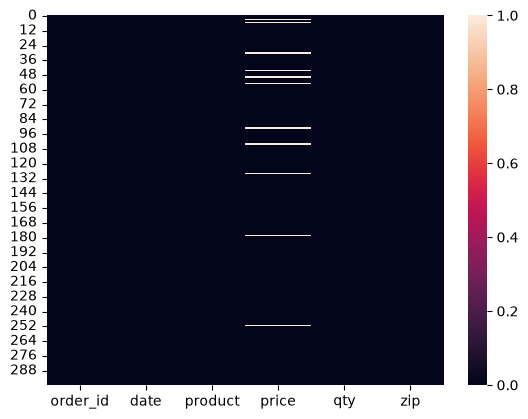

In [7]:
import seaborn as sns
sns.heatmap(salesdf.isnull())

In [8]:
fill_value = salesdf["price"].median()
salesdf["price"] = salesdf["price"].fillna(fill_value)

print(fill_value)

37.53


The mean for "price" skews very high; 75% of its range is ~61.42 and below, but its max value is leagues higher at ~479.29. Even just a few high values have shifted the mean (~56.07) to nearly the 75% mark. The median, (37.53) was used as the fill value instead because it is not sensitive to those very high outliers.

In [9]:
salesdf.isna().sum()

order_id    0
date        0
product     0
price       0
qty         0
zip         0
dtype: int64

In [10]:
salesdf.shape

(300, 6)

In [11]:
salesdf.duplicated().sum()

np.int64(8)

In [12]:
salesdf = salesdf.drop_duplicates()

In [13]:
salesdf.duplicated().sum()

np.int64(0)

In [14]:
salesdf.shape

(292, 6)

In [15]:
salesdf["zip"] = salesdf["zip"].astype(str).str.zfill(5)

In [16]:
salesdf.head(10)

,order_id,date,product,price,qty,zip
0,1254,04/06/2026,mug,11.36,4,60614
1,1057,2026-05-30,charger,14.79,3,30303
2,1150,05/06/2026,mug,5.50,1,10001
3,1066,05/30/2026,notebook,37.53,1,98101
4,1114,04/06/2026,webcam,45.59,4,90405
5,1280,04/22/2026,pen set,37.53,4,30303
6,1204,04/18/2026,charger,8.41,2,02134
7,1249,2026-05-15,keyboard,75.04,4,90405
8,1037,2026-05-19,mug,9.31,2,60614
9,1177,2026-05-13,mug,10.11,3,90210


In [17]:
salesdf["date"] = pd.to_datetime(salesdf["date"], format="mixed")

In [18]:
salesdf.info()

<class 'pandas.DataFrame'>
Index: 292 entries, 0 to 299
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   order_id  292 non-null    int64         
 1   date      292 non-null    datetime64[us]
 2   product   292 non-null    str           
 3   price     292 non-null    float64       
 4   qty       292 non-null    int64         
 5   zip       292 non-null    str           
dtypes: datetime64[us](1), float64(1), int64(2), str(2)
memory usage: 16.0 KB


In [19]:
round(salesdf.describe(),3)

,order_id,date,price,qty
count,292.000,292,292.000,292.000
mean,1145.500,2026-05-01 16:50:57.534246,55.523,2.911
min,1000.000,2026-04-01 00:00:00,2.930,-5.000
25%,1072.750,2026-04-18 00:00:00,11.045,2.000
50%,1145.500,2026-05-02 00:00:00,37.530,3.000
75%,1218.250,2026-05-15 00:00:00,55.510,4.000
max,1291.000,2026-05-30 00:00:00,479.290,5.000
std,84.437,NaN,71.767,1.559


In [20]:
salesdf[salesdf["qty"] < 0]

,order_id,date,product,price,qty,zip
202,1140,2026-04-18,webcam,38.69,-5,98101
262,1233,2026-05-09,desk lamp,22.64,-4,10001
297,1025,2026-04-27,keyboard,47.30,-2,02116


In [21]:
salesdf = salesdf[salesdf["qty"] >= 0]

In [22]:
salesdf[salesdf["qty"] < 0]

,order_id,date,product,price,qty,zip


In [23]:
salesdf[salesdf["qty"] >= 0]

,order_id,date,product,price,qty,zip
0,1254,2026-04-06,mug,11.36,4,60614
1,1057,2026-05-30,charger,14.79,3,30303
2,1150,2026-05-06,mug,5.50,1,10001
3,1066,2026-05-30,notebook,37.53,1,98101
4,1114,2026-04-06,webcam,45.59,4,90405
...,...,...,...,...,...,...
293,1185,2026-05-21,notebook,3.33,1,98101
294,1103,2026-04-21,pen set,16.47,3,90405
296,1067,2026-04-27,backpack,37.93,5,90210
298,1196,2026-04-25,pen set,8.79,3,90405


Three rows were found to have negative values for the "qty" column, which is impossible. There is no information available on why these values were recorded incorrectly, though there are multiple possibilities. It could be that typoes were made while inputting rows; another possibility is that a negative value is to indicate product loss or being returned by the client. Because there is no context and there are only three rows in question, the rows were excluded from the final dataset to keep things simple.

In [24]:
salesdf.shape

(289, 6)

In [25]:
salesdf.to_csv("sales_clean.csv", index=False)

## Cleaning Log:

- 12 rows were missing a value for the "price" column
- missing "price" values were imputed using the median (37.53) rather than the mean to avoid inaccurately skewing the data
- 8 identical duplicates were found and removed from the data, resulting in a shape of (292,6), ie. 292 rows instead of 300
- "zip" column contained entries with deleted trailing zeroes; this was repaired by forcing all values in the column to have 5 digits
- dtype of the "date" column was changed from string to standard date and time in microseconds (datetime64[us])
- some rows had a negative value for the "qty" column; these rows were identified and removed from the data, resulting in a shape of (289, 6) ie. 289 rows instead of 292
- a new version of the file was created, containing cleaned data

I consulted the pandas User Guide through-out this lab. I would also like to acknowledge the official Seaborn website for their installation guide and the website GeeksForGeeks for their explanation of how to use Seaborn. <p>
https://pandas.pydata.org/pandas-docs/stable/reference/index.html <p>
https://seaborn.pydata.org/installing.html <p>
https://www.geeksforgeeks.org/python/seaborn-heatmap-a-comprehensive-guide/

Github Repo Url: https://github.com/journeyrahman/cs82a-portfolio